![logo](../../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Satellite observations completeness for monitor ecosystem health/ water resource management

Production date: 12-07-2024

Produced by: Cristina Deidda (VUB)

## Use case: Utilize satellite-derived lake water temperature data to optimize fisheries management and monitor ecosystem health

## Quality assessment question
* **Are satellite measurements of surface water temperature adequately comprehensive in terms of temporal coverage and data completeness to monitor the temperature dynamics of the Lake Superior (Nord America) ?**

**The lake surface water temperature data from 1995 to the present, derived from satellite observations, provide a time series of water temperature for various lakes around the globe. This dataset can be utilized for multiple applications, such as water resource management to monitor water level temperature, optimizing fisheries management, or monitoring ecosystem health. In this case study, we will focus on Lake Superior, considering the mean water surface temperature for the entire available time series. The objective is to study the completeness of the time series, the data quality, and the possible presence of outliers to determine the suitability of the data for the aforementioned applications.**

## Quality assessment statement

For surface water level monitoring, it is important to check the completeness of the data series before applying any type of statistical analysis. In the case study of mean water lake temperature over Lake Superior (1997-2000), the data series is incomplete, with 54.31% of values missing. The data are provided with 'quality flags' ranging from 0 to 5, with a minimum quality level suggested for data usage.

Quality levels 4 and 5 reflect a higher degree of confidence in the validity of the satellite estimate. The recommendation to users is to use the highest quality level in preference (4 and 5), unless they have specifically verified for a given lake that lower quality levels are fit for their application. Quality level 3 data comparison with the in-situ data shows an agreement that may be acceptable to some users; however, they have to be used with care. Quality level 1 data should never be used, and they are classified as “bad data”, and quality level 2 data should be thoroughly inspected if the use is strictly necessary. For Lake Superior, the data quality is good, mostly higher than 4 for the entire lake surface.

A boxplot analysis reveals the presence of outliers in both the upper and lower parts of the data. By masking the data to include only those with quality flags higher than 4, the number of outliers is reduced. Despite the presence of missing values, the series effectively represents seasonal variation.

```{figure} bd326ec5-9501-4718-9e47-9c49bf51c43d.PNG
---
---
Spatially weighted mean of water temperature for Lake Superior, considering quality flags higher than 0 or 4.
```

Key notes:

* The mean water lake temperature data for Lake Superior (North America) from 1997-2000 is incomplete.
* It is important to mask the data using 'quality flags' and only use data with quality flags >4, as recommended.
* Despite the missing data, the seasonal temperature variation is well represented.
* There may still be some outliers in the data series.
* The quality of data depends on the case study and the lake considered. For some lakes, there may be less data available with a quality level higher than 4.
* This dataset has high potential for water resource management, prior considering the quality flags, missing values, and possible outliers.

## Methodology
The analysis and results are organised in the following steps, which are detailed in the sections below: 

**[](satellite_satellite-lake-water-temperature_data-completeness_q01:section-1)**
 * Download satellite water temperature data selecting boundary box of Lake Superior

**[](satellite_satellite-lake-water-temperature_data-completeness_q01:section-2)**
 * Plot Lake Superior and ID

**[](satellite_satellite-lake-water-temperature_data-completeness_q01:section-3)**
 * Inspect the quality flags
 * Select the data with quality flags higher than 4
 * Calculate percentage of missing values
 * Plot time series for filtered and not filtered data

**[](satellite_satellite-lake-water-temperature_data-completeness_q01:section-4)**
 * Boxplot for filtered (quality flag>4) and not filtered data

## Analysis and results

(satellite_satellite-lake-water-temperature_data-completeness_q01:section-1)=
### 1. Data request and download

### Import packages

In [10]:
import cartopy.crs as ccrs
import matplotlib.cbook
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from c3s_eqc_automatic_quality_control import diagnostics, download, plot, utils

plt.style.use("seaborn-v0_8-notebook")

### Set variables

In [11]:
# Time
start = "1997-01"
stop = "2000-01"

# Region
lon_slice = slice(-92.10, -84.80)
lat_slice = slice(46.30, 49.00)

# Variable
varname = "lake_surface_water_temperature"

### Set the data request

In [15]:
collection_id = "satellite-lake-water-temperature"
request = {
    "version": "4.0",
    "variable": "all",
    "format": "zip",
}

### Download data

In [16]:
requests = download.update_request_date(
    request, start=start, stop=stop, stringify_dates=True
)
ds = download.download_and_transform(
    collection_id,
    requests,
    chunks={"year": 1, "month": 1},
    transform_func=utils.regionalise,
    transform_func_kwargs={"lon_slice": lon_slice, "lat_slice": lat_slice},
)

100%|██████████| 37/37 [00:06<00:00,  5.47it/s]


(satellite_satellite-lake-water-temperature_data-completeness_q01:section-2)=
### 2. Plot lakeid

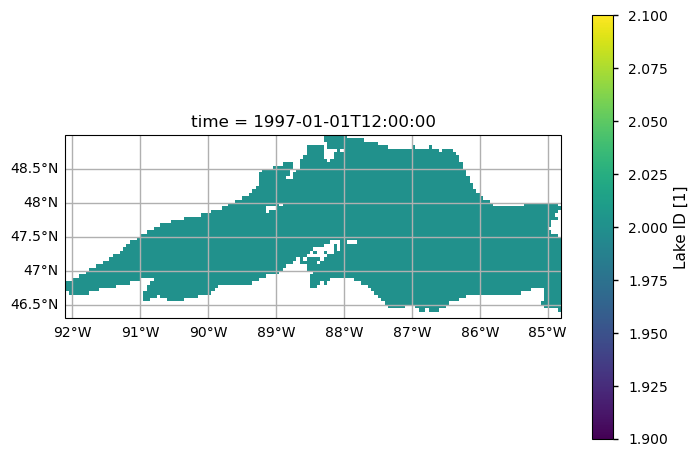

In [17]:
_ = plot.projected_map(
    ds["lakeid"].isel(time=0),
    projection=ccrs.PlateCarree(),
    show_stats=False,
)

(satellite_satellite-lake-water-temperature_data-completeness_q01:section-3)=
### 3. Compute and plot spatial weighten mean

### Compute spatial weighted mean

In [18]:
# Reindex using lakeids and min_quality_level
lakeid = (
    xr.DataArray(np.unique(ds["lakeid"].values), dims=("lakeid"))
    .dropna("lakeid")
    .astype(int)
)
min_quality_level = xr.DataArray([0, 4], dims=("min_quality_level"))
ds = ds.drop_vars("lakeid").where(ds["lakeid"] == lakeid)
ds = ds.where(ds["quality_level"] >= min_quality_level)
ds = ds.assign_coords(lakeid=lakeid, min_quality_level=min_quality_level)

# Spatial weighted mean
da = diagnostics.spatial_weighted_mean(ds[varname])

### Plot spatial weighted mean

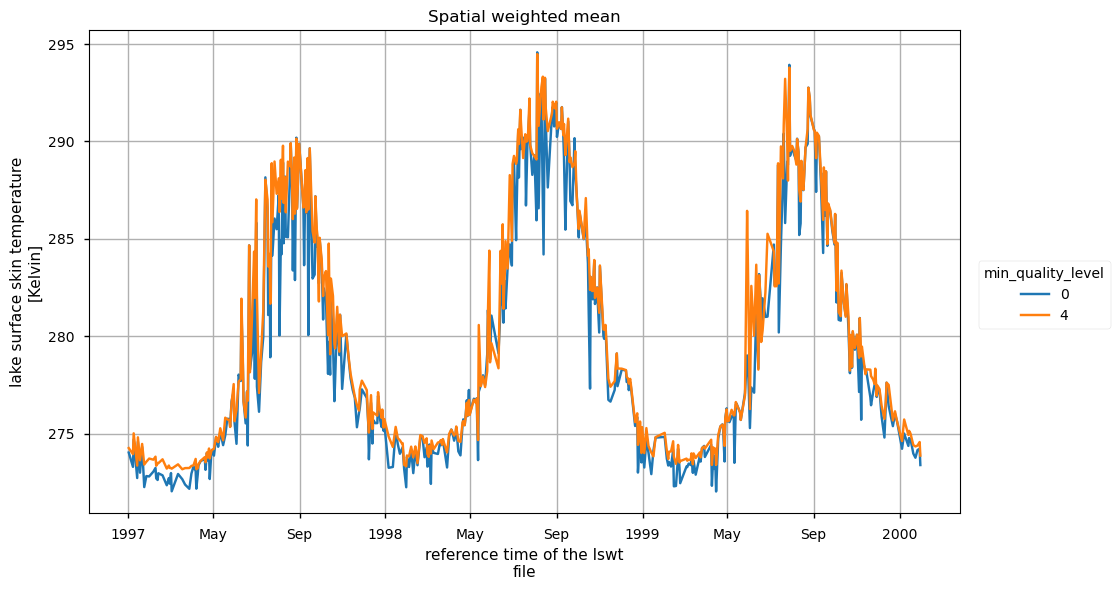

Missing values of lake ID 2: 54.31 %


In [19]:
da.dropna("time").plot(hue="min_quality_level", col="lakeid", figsize=(10, 6))
plt.grid()
plt.title("Spatial weighted mean")
plt.show()

# Print missing values
missings = da.sel(min_quality_level=0).isnull().sum("time") / da.sizes["time"] * 100
for lakeid, missing in missings.groupby("lakeid", squeeze=False):
    print(f"Missing values of lake ID {lakeid}: {float(missing.squeeze()):.2f} %")

(satellite_satellite-lake-water-temperature_data-completeness_q01:section-4)=
### 4. Boxplot

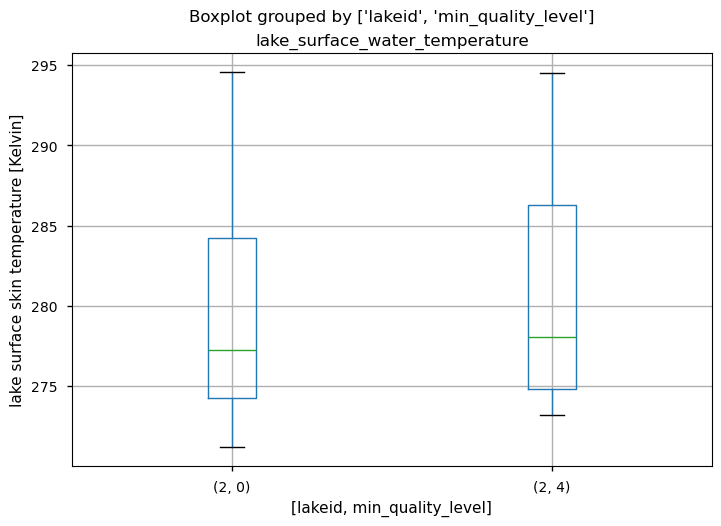

2            
                 0           4
mean    279.330414  280.373108
iqr       9.943016   11.474396
cilo    276.537485  277.213921
cihi    277.928182  278.881172
whishi  294.574585  294.485535
whislo  271.199982  273.166138
fliers          []          []
q1      274.277504  274.810059
med     277.232834  278.047546
q3       284.22052  286.284454

In [20]:
df = da.to_dataframe()
df.boxplot(by=(["lakeid", "min_quality_level"]))
plt.ylabel(f"{da.attrs['long_name']} [{da.attrs['units']}]")
plt.show()

# Show stats
stats = {}
for label, grouped_df in df.groupby(["lakeid", "min_quality_level"]):
    (stats[label],) = matplotlib.cbook.boxplot_stats(
        grouped_df.dropna().values.squeeze()
    )
pd.DataFrame(stats)